<ipython-input-8-b9cecf950ead>:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['Date'] = pd.date_range(start='1982-01-01', periods=len(df), freq='M')


Análisis estadístico descriptivo:
             TB3M        TB6M
count  234.000000  234.000000
mean     6.315598    6.564274
std      2.197159    2.308606
min      2.930000    3.040000
25%      5.080000    5.230000
50%      5.825000    6.035000
75%      7.895000    7.950000
max     14.280000   14.810000


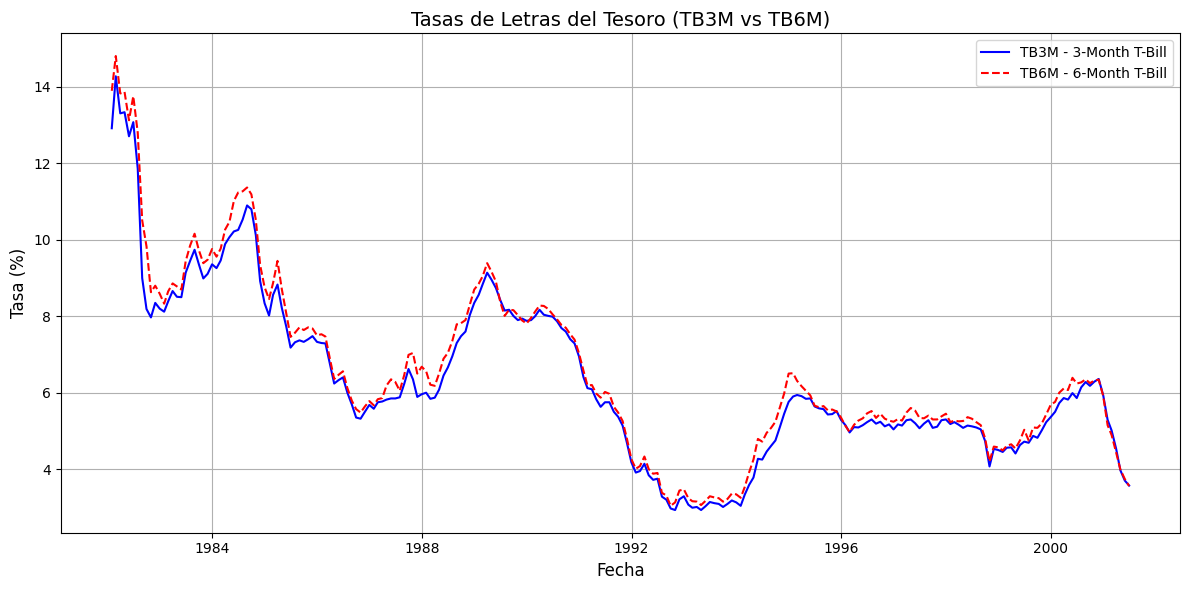

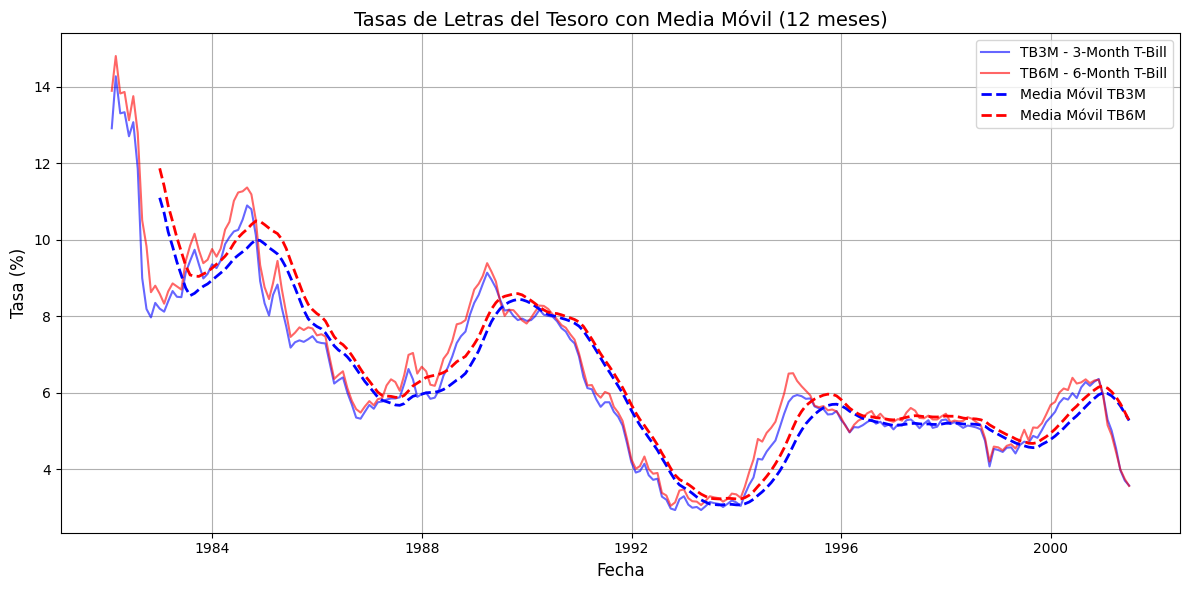


Correlación entre TB3M y TB6M:
          TB3M      TB6M
TB3M  1.000000  0.996085
TB6M  0.996085  1.000000

📊 ADF Test para TB3M
Estadístico ADF: -1.5392
Valor p: 0.5140
Número de rezagos utilizados: 10
Número de observaciones usadas: 223
Valores críticos:
  1%: -3.4600
  5%: -2.8746
  10%: -2.5737
❌ La serie TB3M NO es estacionaria (no se rechaza H0).

📊 ADF Test para TB6M
Estadístico ADF: -3.7738
Valor p: 0.0032
Número de rezagos utilizados: 1
Número de observaciones usadas: 232
Valores críticos:
  1%: -3.4589
  5%: -2.8741
  10%: -2.5735
✅ La serie TB6M es estacionaria (se rechaza H0 de raíz unitaria).

📊 KPSS Test para TB3M
Estadístico KPSS: 1.4540
Valor p: 0.0100
❌ La serie TB3M NO es estacionaria (se rechaza H0 de estacionariedad).

📊 KPSS Test para TB6M
Estadístico KPSS: 1.4961
Valor p: 0.0100
❌ La serie TB6M NO es estacionaria (se rechaza H0 de estacionariedad).


<ipython-input-8-b9cecf950ead>:79: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado = kpss(serie.dropna(), regression='c', nlags='auto')
<ipython-input-8-b9cecf950ead>:79: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado = kpss(serie.dropna(), regression='c', nlags='auto')


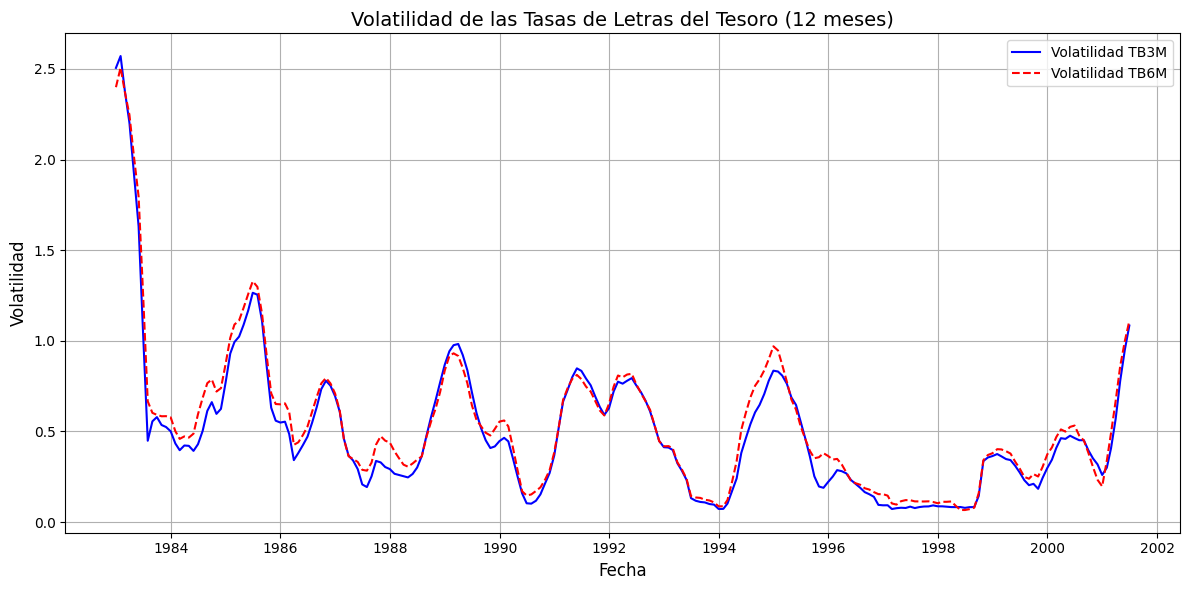

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

# === 1. Cargar archivo Excel ===
archivo = '22.7.xlsx'  # Asegúrate de que esté en tu carpeta de trabajo
df = pd.read_excel(archivo)

# Ajustar nombres de columna si es necesario
df.columns = ['Index', 'TB3M', 'TB6M']

# Crear una serie de fechas (mensual) desde enero 1982
df['Date'] = pd.date_range(start='1982-01-01', periods=len(df), freq='M')
df.set_index('Date', inplace=True)

# === 2. Análisis Estadístico Descriptivo ===
print("Análisis estadístico descriptivo:")
print(df[['TB3M', 'TB6M']].describe())

# === 3. Graficar ambas series en el mismo diagrama ===
plt.figure(figsize=(12, 6))
plt.plot(df['TB3M'], label='TB3M - 3-Month T-Bill', color='blue')
plt.plot(df['TB6M'], label='TB6M - 6-Month T-Bill', color='red', linestyle='--')
plt.title('Tasas de Letras del Tesoro (TB3M vs TB6M)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Tasa (%)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 4. Análisis de Tendencia (Media Móvil) ===
df['TB3M_MA'] = df['TB3M'].rolling(window=12).mean()  # Media móvil de 12 meses
df['TB6M_MA'] = df['TB6M'].rolling(window=12).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['TB3M'], label='TB3M - 3-Month T-Bill', color='blue', alpha=0.6)
plt.plot(df['TB6M'], label='TB6M - 6-Month T-Bill', color='red', alpha=0.6)
plt.plot(df['TB3M_MA'], label='Media Móvil TB3M', color='blue', linestyle='--', linewidth=2)
plt.plot(df['TB6M_MA'], label='Media Móvil TB6M', color='red', linestyle='--', linewidth=2)
plt.title('Tasas de Letras del Tesoro con Media Móvil (12 meses)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Tasa (%)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 5. Correlación entre TB3M y TB6M ===
correlacion = df[['TB3M', 'TB6M']].corr()
print("\nCorrelación entre TB3M y TB6M:")
print(correlacion)

# === 6. Prueba de raíz unitaria (ADF) ===
def prueba_adf(serie, nombre):
    resultado = adfuller(serie.dropna(), autolag='AIC')
    print(f'\n📊 ADF Test para {nombre}')
    print(f'Estadístico ADF: {resultado[0]:.4f}')
    print(f'Valor p: {resultado[1]:.4f}')
    print(f'Número de rezagos utilizados: {resultado[2]}')
    print(f'Número de observaciones usadas: {resultado[3]}')
    print('Valores críticos:')
    for clave, valor in resultado[4].items():
        print(f'  {clave}: {valor:.4f}')
    if resultado[1] < 0.05:
        print(f'✅ La serie {nombre} es estacionaria (se rechaza H0 de raíz unitaria).')
    else:
        print(f'❌ La serie {nombre} NO es estacionaria (no se rechaza H0).')

# Ejecutar prueba ADF para cada serie
prueba_adf(df['TB3M'], 'TB3M')
prueba_adf(df['TB6M'], 'TB6M')



# === 7. Prueba de estacionariedad KPSS ===
def prueba_kpss(serie, nombre):
    # Cambié 'lags' por 'nlags' para usar el argumento correcto
    resultado = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f'\n📊 KPSS Test para {nombre}')
    print(f'Estadístico KPSS: {resultado[0]:.4f}')
    print(f'Valor p: {resultado[1]:.4f}')
    if resultado[1] < 0.05:
        print(f'❌ La serie {nombre} NO es estacionaria (se rechaza H0 de estacionariedad).')
    else:
        print(f'✅ La serie {nombre} es estacionaria (no se rechaza H0).')

# Ejecutar prueba KPSS para cada serie
prueba_kpss(df['TB3M'], 'TB3M')
prueba_kpss(df['TB6M'], 'TB6M')

# === 8. Análisis de Volatilidad (Desviación estándar mensual) ===
df['TB3M_vol'] = df['TB3M'].rolling(window=12).std()  # Desviación estándar de 12 meses
df['TB6M_vol'] = df['TB6M'].rolling(window=12).std()

plt.figure(figsize=(12, 6))
plt.plot(df['TB3M_vol'], label='Volatilidad TB3M', color='blue')
plt.plot(df['TB6M_vol'], label='Volatilidad TB6M', color='red', linestyle='--')
plt.title('Volatilidad de las Tasas de Letras del Tesoro (12 meses)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Volatilidad', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
